# 03 — Phân tích khám phá dữ liệu (EDA)

Trực quan hóa phân bố thời gian điều trị và vị trí địa lý của bệnh nhân. **Đầu vào**: `data/processed/model_df.pkl`.

### Import & nạp dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import config

In [2]:
model_df = pd.read_pickle(config.MODEL_DF_PKL)
model_df.head()

,Tuổi,DANTOC,Tháng nhập viện,TONGCP,Thời gian điều trị,Vùng miền,Kinh độ,Vĩ độ,Số lượng bệnh/hỗ trợ y tế,Số lượng danh mục bệnh I,...,Số lượng danh mục bệnh XIII,Số lượng danh mục bệnh XIV,Số lượng danh mục bệnh XV,Số lượng danh mục bệnh XVI,Số lượng danh mục bệnh XVII,Số lượng danh mục bệnh XVIII,Số lượng danh mục bệnh XIX,Số lượng danh mục bệnh XX,Số lượng danh mục bệnh XXI,Số lượng danh mục bệnh XXII
0,28,Kinh,1,15000.00000,0.006250,Nam Trung Bộ,109.220755,13.767370,1,0,...,0,0,0,0,0,0,1,0,0,0
1,18,Kinh,1,83346.50000,0.073611,Nam Trung Bộ,109.220755,13.767370,1,0,...,0,0,0,0,0,0,0,0,0,0
2,36,Kinh,1,159.99900,0.061806,Nam Trung Bộ,109.126417,13.886814,2,0,...,0,0,0,1,0,0,0,0,0,0
3,5,Kinh,12,112938.00000,2.440972,Nam Trung Bộ,109.222706,13.768971,1,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Kinh,12,262395.00025,6.927778,Nam Trung Bộ,109.220755,13.767370,2,1,...,0,0,0,0,0,0,0,0,0,0


In [3]:
model_df.info()

<class 'pandas.DataFrame'>
Index: 67036 entries, 0 to 68761
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Tuổi                          67036 non-null  int64  
 1   DANTOC                        67036 non-null  str    
 2   Tháng nhập viện               67036 non-null  int32  
 3   TONGCP                        67036 non-null  float64
 4   Thời gian điều trị            67036 non-null  float64
 5   Vùng miền                     67036 non-null  str    
 6   Kinh độ                       67036 non-null  float64
 7   Vĩ độ                         67036 non-null  float64
 8   Số lượng bệnh/hỗ trợ y tế     67036 non-null  int64  
 9   Số lượng danh mục bệnh I      67036 non-null  int64  
 10  Số lượng danh mục bệnh II     67036 non-null  int64  
 11  Số lượng danh mục bệnh III    67036 non-null  int64  
 12  Số lượng danh mục bệnh IV     67036 non-null  int64  
 13  Số lượng danh mục

### Phân bố thời gian điều trị

<Axes: xlabel='Thời gian điều trị', ylabel='Count'>

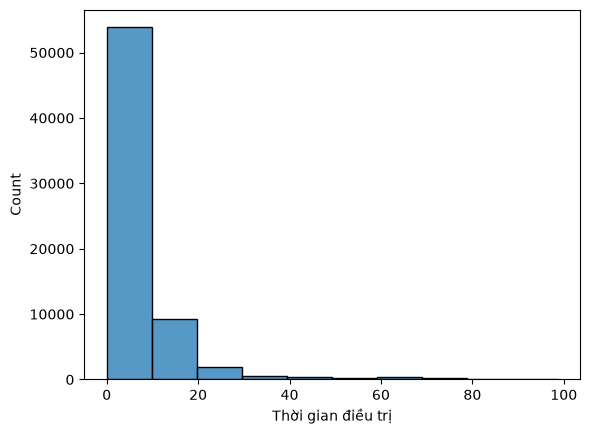

In [24]:
sns.histplot(data = model_df[model_df['Thời gian điều trị'] <= 100], x = 'Thời gian điều trị', bins = 10)

### Ma trận tương quan (correlation heatmap)
Chỉ tính trên các cột **số**; hai cột phân loại `DANTOC`, `Vùng miền` được loại. Tên 22 nhóm bệnh ICD được rút gọn cho dễ đọc, và nửa trên ma trận được ẩn (do đối xứng).

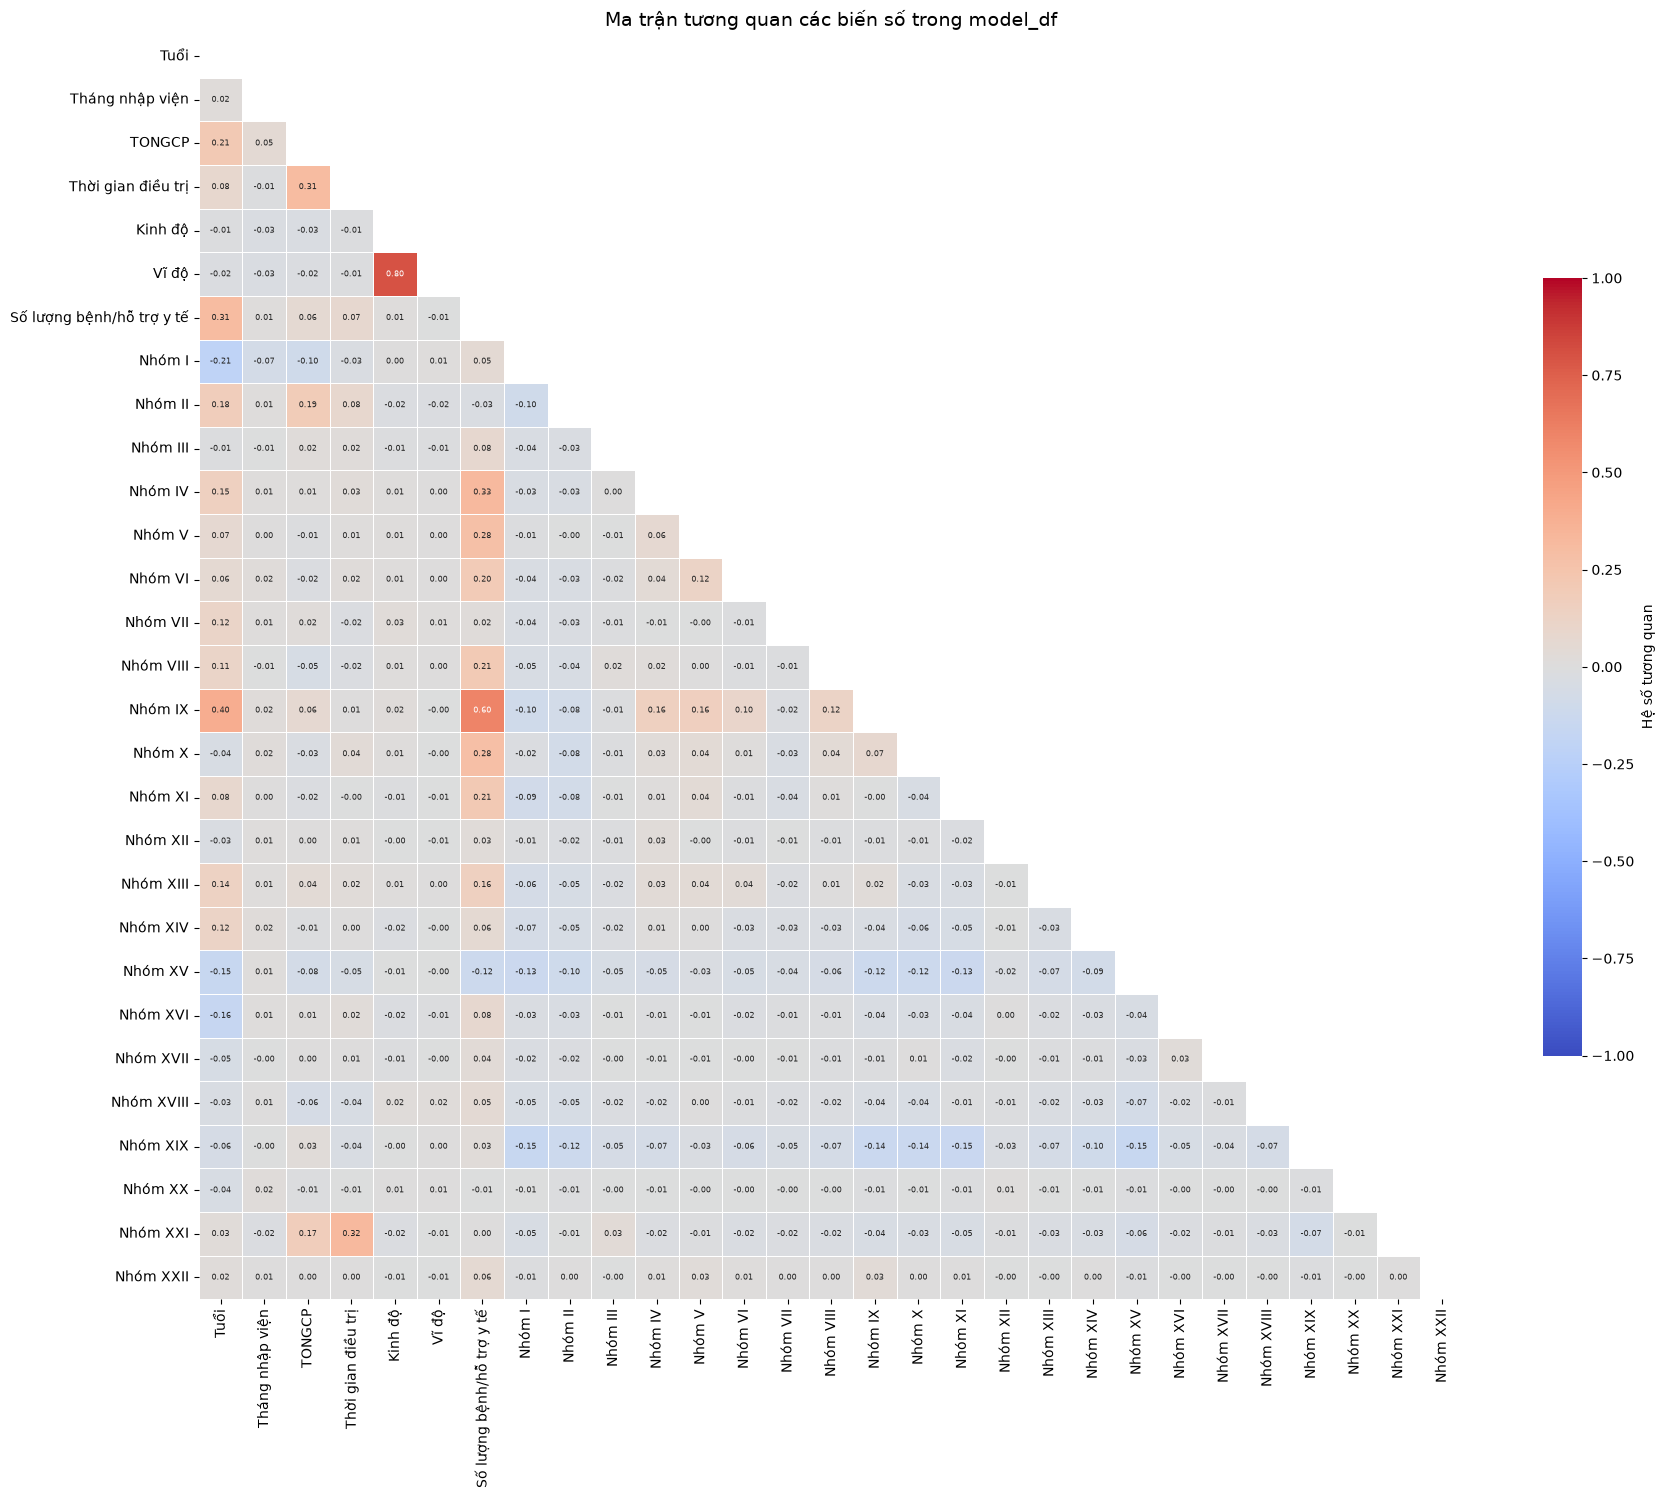

In [5]:
import numpy as np

# Lấy cột số; rút gọn tên 22 nhóm bệnh ICD cho dễ đọc trên trục
corr_df = model_df.select_dtypes('number').rename(
    columns=lambda c: c.replace('Số lượng danh mục bệnh', 'Nhóm')
    if c.startswith('Số lượng danh mục bệnh') else c
)
corr = corr_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # ẩn nửa trên (ma trận đối xứng)
plt.figure(figsize=(18, 15))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 6}, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.6, 'label': 'Hệ số tương quan'})
plt.title('Ma trận tương quan các biến số trong model_df', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Lọc các cặp biến có |corr| >= 0.2
mask_lower = np.tril(np.ones_like(corr, dtype=bool), k=-1)
pairs = (
    corr.where(mask_lower)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Biến 1', 'level_1': 'Biến 2', 0: 'Tương quan'})
)
pairs['|Tương quan|'] = pairs['Tương quan'].abs()

strong_pairs = (
    pairs[pairs['|Tương quan|'] >= 0.3]
    .sort_values('|Tương quan|', ascending=False)
    .reset_index(drop=True)
)
strong_pairs

,Biến 1,Biến 2,Tương quan,|Tương quan|
0,Vĩ độ,Kinh độ,0.797714,0.797714
1,Nhóm IX,Số lượng bệnh/hỗ trợ y tế,0.600109,0.600109
2,Nhóm IX,Tuổi,0.395674,0.395674
3,Nhóm IV,Số lượng bệnh/hỗ trợ y tế,0.326980,0.326980
4,Nhóm XXI,Thời gian điều trị,0.322838,0.322838
5,Thời gian điều trị,TONGCP,0.308741,0.308741
6,Số lượng bệnh/hỗ trợ y tế,Tuổi,0.305564,0.305564


### Phân bố nhân khẩu học

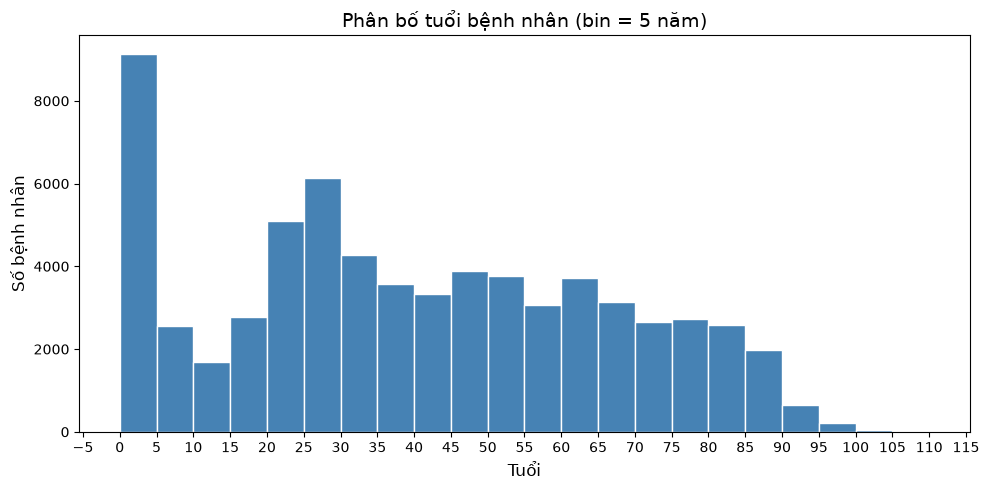

In [14]:
age_min = model_df['Tuổi'].min()
age_max = model_df['Tuổi'].max()
bins = range(age_min - (age_min % 5), age_max + 6, 5)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(model_df['Tuổi'], bins=list(bins), edgecolor='white', color='steelblue')
ax.set_xlabel('Tuổi', fontsize=12)
ax.set_ylabel('Số bệnh nhân', fontsize=12)
ax.set_title('Phân bố tuổi bệnh nhân (bin = 5 năm)', fontsize=14)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
plt.tight_layout()
plt.show()

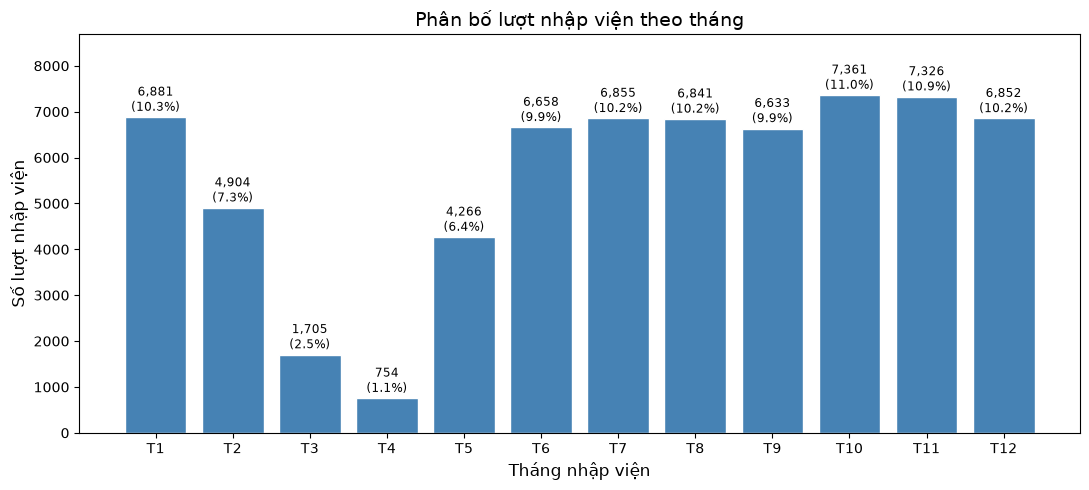

In [15]:
# Bar chart tháng nhập viện — count + percentage label trên mỗi bar
month_counts = model_df['Tháng nhập viện'].value_counts().sort_index()
total = month_counts.sum()
month_labels = [f'T{m}' for m in month_counts.index]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(month_labels, month_counts.values, color='steelblue', edgecolor='white')

for bar, count in zip(bars, month_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Tháng nhập viện', fontsize=12)
ax.set_ylabel('Số lượt nhập viện', fontsize=12)
ax.set_title('Phân bố lượt nhập viện theo tháng', fontsize=14)
ax.margins(y=0.18)
plt.tight_layout()
plt.show()

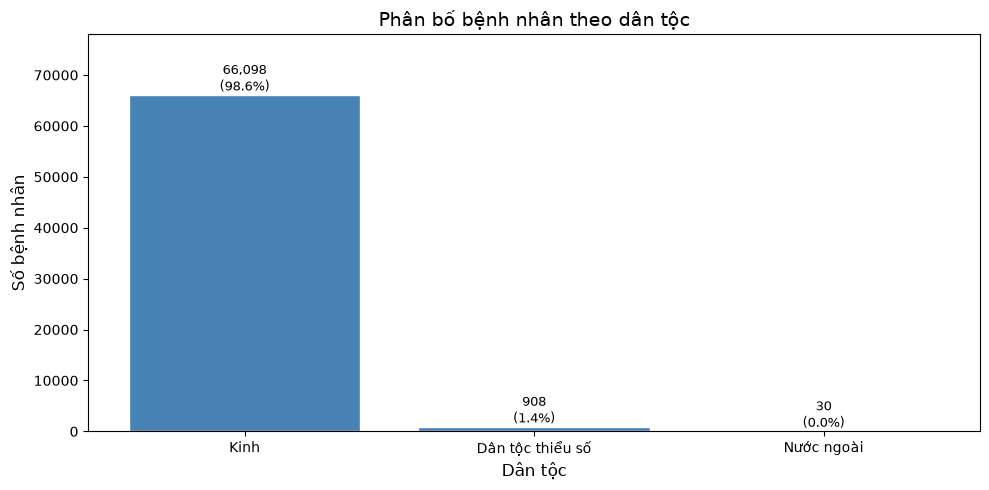

In [17]:
# Bar chart dân tộc — count + percentage label trên mỗi bar
dan_toc = model_df['DANTOC'].value_counts().sort_values(ascending=False)
total = dan_toc.sum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dan_toc.index, dan_toc.values, color='steelblue', edgecolor='white')

for bar, count in zip(bars, dan_toc.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Dân tộc', fontsize=12)
ax.set_ylabel('Số bệnh nhân', fontsize=12)
ax.set_title('Phân bố bệnh nhân theo dân tộc', fontsize=14)
ax.margins(y=0.18)
plt.tight_layout()
plt.show()

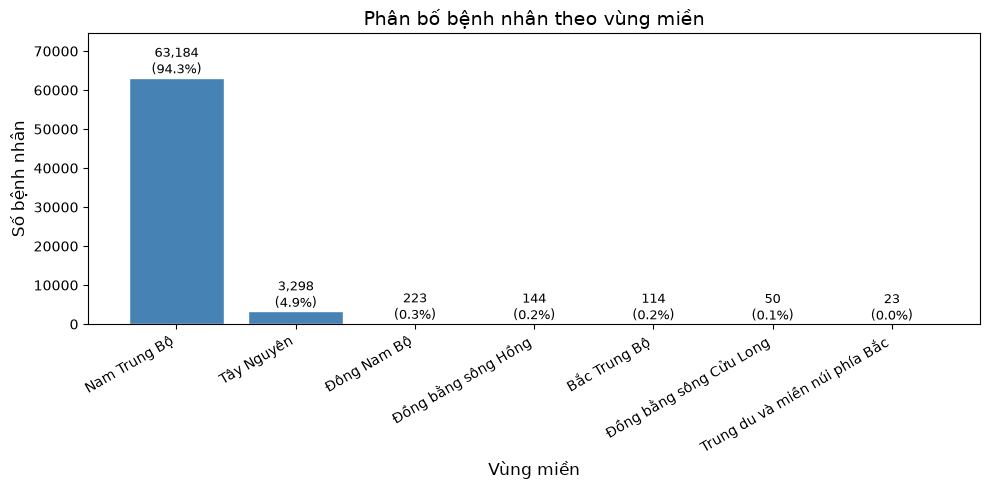

In [21]:
# Bar chart vùng miền — count + percentage label trên mỗi bar
vung_mien = model_df['Vùng miền'].value_counts().sort_values(ascending=False)
total = vung_mien.sum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(vung_mien.index, vung_mien.values, color='steelblue', edgecolor='white')

for bar, count in zip(bars, vung_mien.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Vùng miền', fontsize=12)
ax.set_ylabel('Số bệnh nhân', fontsize=12)
ax.set_title('Phân bố bệnh nhân theo vùng miền', fontsize=14)
ax.margins(y=0.18)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Kiểm định Kruskal-Wallis — categorical vs. Thời gian điều trị

In [27]:
from scipy.stats import kruskal

target = 'Thời gian điều trị'
cat_cols = ['DANTOC', 'Vùng miền', 'Tháng nhập viện']

def sig_label(p):
    if p < 0.001:
        return 'Có quan hệ (p < 0.001)'
    elif p < 0.05:
        return 'Có quan hệ (p < 0.05)'
    else:
        return 'Không có quan hệ (p >= 0.05)'

results = []
for col in cat_cols:
    groups = [grp[target].values for _, grp in model_df.groupby(col)]
    stat, p = kruskal(*groups)
    k = len(groups)
    n = len(model_df)
    eta2 = (stat - k + 1) / (n - k)
    results.append({
        'Biến': col,
        'Số nhóm (k)': k,
        'H-statistic': round(stat, 4),
        'p-value': p,
        'Eta² (effect size)': round(eta2, 6),
    })

kw_df = pd.DataFrame(results).set_index('Biến')
kw_df.style.format({'p-value': '{:.2e}', 'H-statistic': '{:.4f}', 'Eta² (effect size)': '{:.6f}'})

,Số nhóm (k),H-statistic,p-value,Eta² (effect size)
Biến,,,,
DANTOC,3,65.9826,4.70e-15,0.000954
Vùng miền,7,298.5808,1.65e-61,0.004365
Tháng nhập viện,12,979.3421,5.35e-203,0.014448


### Kiểm định Spearman — numeric features vs. Thời gian điều trị

In [30]:
from scipy.stats import spearmanr

def test_features_vs_target(df, target, exclude=None):
    """Spearman ρ giữa từng numeric feature và target. Sắp xếp theo |ρ| giảm dần."""
    exclude = set(exclude or []) | {target}
    num_cols = [c for c in df.select_dtypes('number').columns if c not in exclude]

    rows = []
    for col in num_cols:
        rho, p = spearmanr(df[col], df[target])
        rows.append({
            'Feature': col,
            'Spearman ρ': round(rho, 4),
            '|ρ|': round(abs(rho), 4),
            'p-value': p,
            'Kết luận': (
                'Có quan hệ (p < 0.001)' if p < 0.001
                else 'Có quan hệ (p < 0.05)' if p < 0.05
                else 'Không có quan hệ (p >= 0.05)'
            ),
        })

    return (
        pd.DataFrame(rows)
        .set_index('Feature')
        .sort_values('|ρ|', ascending=False)
    )


result_df = test_features_vs_target(
    model_df,
    target='Thời gian điều trị',
    exclude=['TONGCP'],
)
result_df.style.format({'Spearman ρ': '{:.4f}', '|ρ|': '{:.4f}', 'p-value': '{:.2e}'})

,Spearman ρ,|ρ|,p-value,Kết luận
Feature,,,,
Số lượng bệnh/hỗ trợ y tế,0.2433,0.2433,0.00e+00,Có quan hệ (p < 0.001)
Tuổi,0.1799,0.1799,0.00e+00,Có quan hệ (p < 0.001)
Số lượng danh mục bệnh XXI,0.1748,0.1748,0.00e+00,Có quan hệ (p < 0.001)
Số lượng danh mục bệnh X,0.1592,0.1592,0.00e+00,Có quan hệ (p < 0.001)
Số lượng danh mục bệnh II,0.1390,0.1390,2.00e-286,Có quan hệ (p < 0.001)
Số lượng danh mục bệnh XVIII,-0.1368,0.1368,1.54e-277,Có quan hệ (p < 0.001)
Kinh độ,-0.1342,0.1342,8.48e-267,Có quan hệ (p < 0.001)
Số lượng danh mục bệnh XIX,-0.1260,0.1260,4.05e-235,Có quan hệ (p < 0.001)
Số lượng danh mục bệnh IV,0.0930,0.0930,8.71e-129,Có quan hệ (p < 0.001)


### Phân vị (Quantile Plot) — Thời gian điều trị

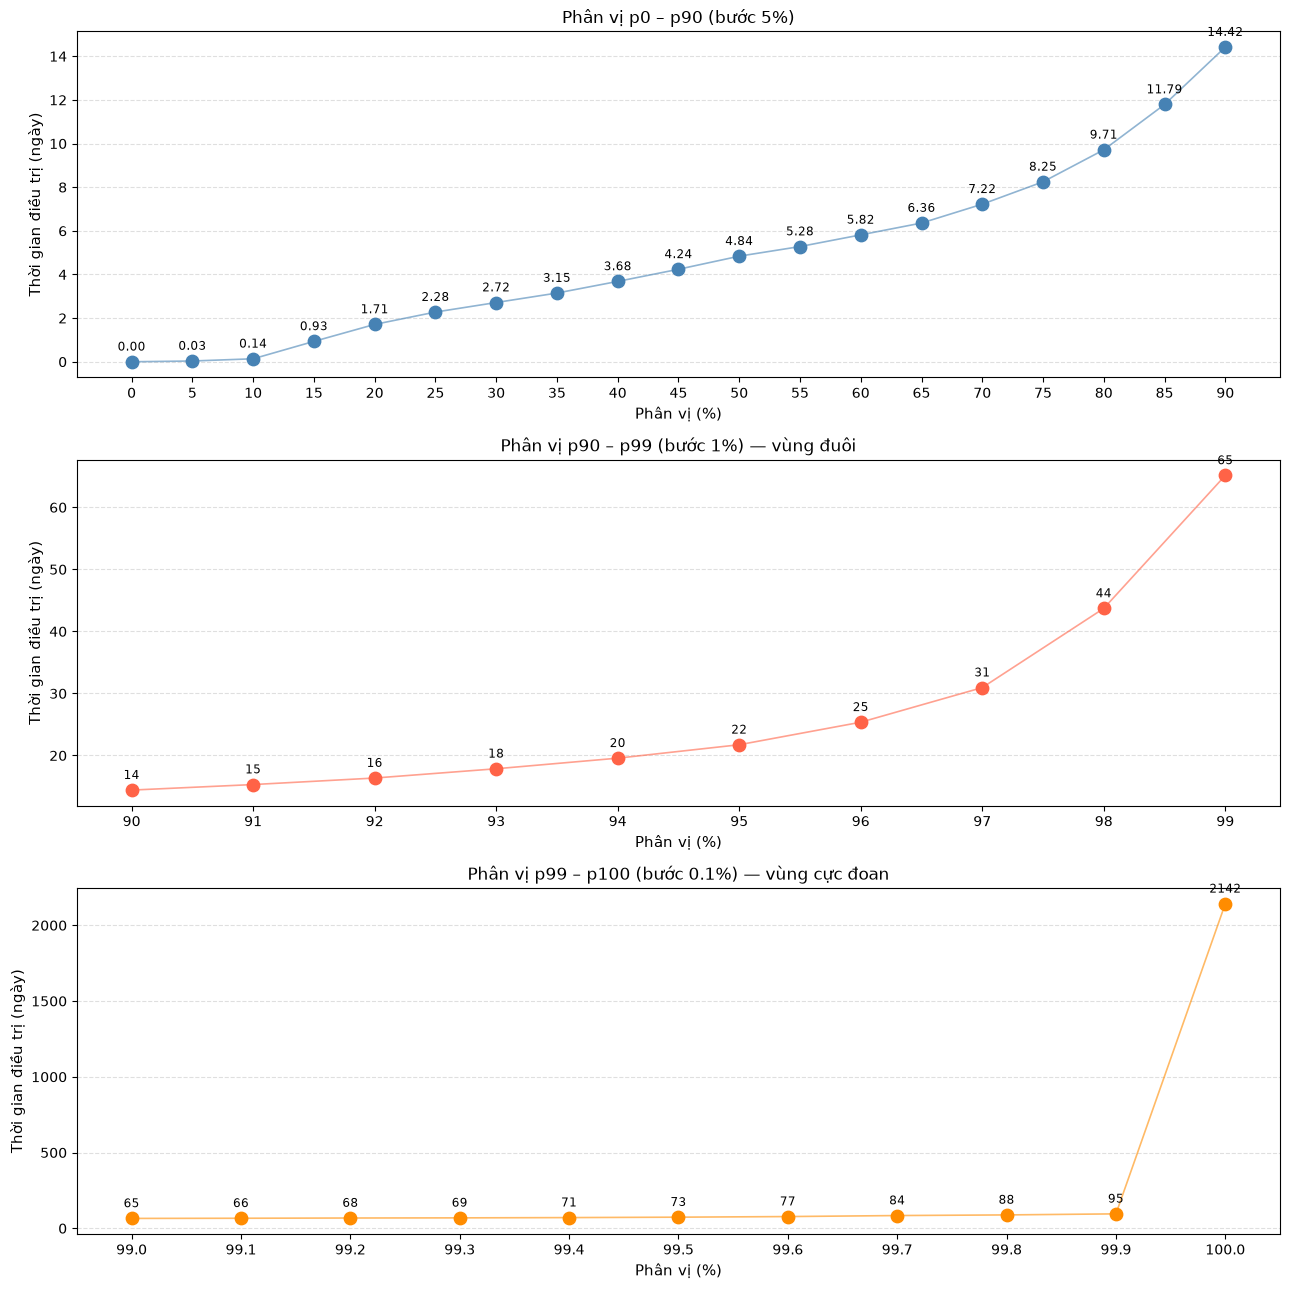

In [54]:
col = 'Thời gian điều trị'

p_main    = np.arange(0, 91, 5)
v_main    = np.percentile(model_df[col], p_main)

p_tail    = np.arange(90, 100, 1)          # p90 – p99, bỏ p100
v_tail    = np.percentile(model_df[col], p_tail)

p_extreme = np.round(np.arange(99, 100.1, 0.1), 1)   # p99 – p100, bước 0.1
v_extreme = np.percentile(model_df[col], p_extreme)

fig, axes = plt.subplots(3, 1, figsize=(13, 13))

# Subplot 1: p0 – p90, bước 5
ax = axes[0]
ax.scatter(p_main, v_main, color='steelblue', s=80, zorder=3)
ax.plot(p_main, v_main, color='steelblue', linewidth=1.2, alpha=0.6)
for p, v in zip(p_main, v_main):
    ax.annotate(f'{v:.2f}', (p, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8.5)
ax.set_xticks(p_main)
ax.set_xlabel('Phân vị (%)', fontsize=11)
ax.set_ylabel('Thời gian điều trị (ngày)', fontsize=11)
ax.set_title('Phân vị p0 – p90 (bước 5%)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Subplot 2: p90 – p99, bước 1
ax = axes[1]
ax.scatter(p_tail, v_tail, color='tomato', s=80, zorder=3)
ax.plot(p_tail, v_tail, color='tomato', linewidth=1.2, alpha=0.6)
for p, v in zip(p_tail, v_tail):
    ax.annotate(f'{round(v):.0f}', (p, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8.5)
ax.set_xticks(p_tail)
ax.set_xlabel('Phân vị (%)', fontsize=11)
ax.set_ylabel('Thời gian điều trị (ngày)', fontsize=11)
ax.set_title('Phân vị p90 – p99 (bước 1%) — vùng đuôi', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Subplot 3: p99 – p100, bước 0.1
ax = axes[2]
ax.scatter(p_extreme, v_extreme, color='darkorange', s=80, zorder=3)
ax.plot(p_extreme, v_extreme, color='darkorange', linewidth=1.2, alpha=0.6)
for p, v in zip(p_extreme, v_extreme):
    ax.annotate(f'{round(v):.0f}', (p, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8.5)
ax.set_xticks(p_extreme)
ax.set_xlabel('Phân vị (%)', fontsize=11)
ax.set_ylabel('Thời gian điều trị (ngày)', fontsize=11)
ax.set_title('Phân vị p99 – p100 (bước 0.1%) — vùng cực đoan', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [68]:
counts = model_df.iloc[:, 9:][model_df['Thời gian điều trị'] <= 1].sum()
pd.DataFrame({
    'count': counts,
    '%': (counts / len(model_df) * 100).round(2)
})


,count,%
Số lượng danh mục bệnh I,710,1.06
Số lượng danh mục bệnh II,346,0.52
Số lượng danh mục bệnh III,21,0.03
Số lượng danh mục bệnh IV,197,0.29
Số lượng danh mục bệnh V,26,0.04
Số lượng danh mục bệnh VI,82,0.12
Số lượng danh mục bệnh VII,33,0.05
Số lượng danh mục bệnh VIII,236,0.35
Số lượng danh mục bệnh IX,1283,1.91
Số lượng danh mục bệnh X,330,0.49
